In [3]:
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments

from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate
import torch

In [5]:
from datasets import load_dataset

In [9]:
# load_dataset??

In [11]:
ds = load_dataset('cornell-movie-review-data/rotten_tomatoes')

In [13]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [15]:
ds_train = ds["train"]
ds_validation = ds["validation"]
ds_test = ds["test"]

In [19]:
df_train = ds_train.to_pandas()

In [21]:
df_train.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [23]:
df_train["label"].value_counts()

label
1    4265
0    4265
Name: count, dtype: int64

In [25]:
s = "effective but too-tepid biopic"
len(s)

30

In [27]:
s = "I like Mango"
len(s)

12

In [29]:
df_train["text_length"] = df_train["text"].apply(len)

In [31]:
df_train.head()

,text,label,text_length
0,the rock is destined to be the 21st century's ...,1,177
1,"the gorgeously elaborate continuation of "" the...",1,226
2,effective but too-tepid biopic,1,30
3,if you sometimes like to go to the movies to h...,1,89
4,"emerges as something rare , an issue movie tha...",1,111


In [33]:
df_train["text_length"].describe()

count    8530.000000
mean      113.971630
std        51.052231
min         4.000000
25%        76.000000
50%       111.000000
75%       149.000000
max       267.000000
Name: text_length, dtype: float64

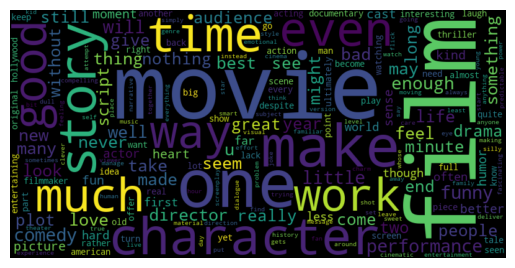

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df_train['text'].tolist())
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [37]:
import re
import unicodedata

def clean_text(text):
    # Normalize unicode
    text = unicodedata.normalize("NFKD", text)
    
    # Remove HTML tags like <br/>
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Remove non-printable characters
    text = ''.join(ch for ch in text if ch.isprintable())
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [ ]:
#small-large
#cased-uncased

In [39]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [41]:
def preprocess_and_tokenize(batch):
    batch["text"] = [clean_text(x) for x in batch["text"]]
    return tokenizer(batch["text"], truncation=True)

In [43]:
clean_dataset = ds.map(preprocess_and_tokenize, batched=True)

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

In [45]:
clean_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
})

In [47]:
ds_train = clean_dataset["train"]
ds_val = clean_dataset["validation"]
ds_test = clean_dataset["test"]

In [51]:
df1 = ds_train.to_pandas()

In [53]:
df1.head()

,text,label,input_ids,token_type_ids,attention_mask
0,the rock is destined to be the 21st century's ...,1,"[101, 1996, 2600, 2003, 16036, 2000, 2022, 199...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"the gorgeously elaborate continuation of "" the...",1,"[101, 1996, 9882, 2135, 9603, 13633, 1997, 100...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,effective but too-tepid biopic,1,"[101, 4621, 2021, 2205, 1011, 8915, 23267, 160...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,if you sometimes like to go to the movies to h...,1,"[101, 2065, 2017, 2823, 2066, 2000, 2175, 2000...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"emerges as something rare , an issue movie tha...",1,"[101, 19391, 2004, 2242, 4678, 1010, 2019, 327...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [55]:
df1["text"][0]

'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .'

In [57]:
df1["input_ids"][0]

array([  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,
        2301,  1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,
        2002,  1005,  1055,  2183,  2000,  2191,  1037, 17624,  2130,
        3618,  2084,  7779, 29058,  8625, 13327,  1010,  3744,  1011,
       18856, 19513,  3158,  5477,  4168,  2030,  7112, 16562,  2140,
        1012,   102], dtype=int32)

In [59]:
len(df1["input_ids"][0])

47

In [61]:
len(df1["input_ids"][1])

52

In [65]:
# DataCollatorWithPadding??

In [67]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [69]:
data_collator

DataCollatorWithPadding(tokenizer=BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')

In [71]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [73]:
training_args = TrainingArguments(
    "bert-rotten-tomatoes",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

In [75]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [77]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=clean_dataset["train"],
    eval_dataset=clean_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/var/folders/gc/npgf58h95t16nm6m6d8q9pcr0000gn/T/ipykernel_8805/1473611205.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.393300,0.365773,0.846154
2,0.215300,0.440479,0.859287
3,0.126200,0.599979,0.858349


TrainOutput(global_step=1602, training_loss=0.2362633775384834, metrics={'train_runtime': 912.5121, 'train_samples_per_second': 28.043, 'train_steps_per_second': 1.756, 'total_flos': 641670308479680.0, 'train_loss': 0.2362633775384834, 'epoch': 3.0})

In [78]:
save_path = "sentiment-bert-model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

('sentiment-bert-model/tokenizer_config.json',
 'sentiment-bert-model/special_tokens_map.json',
 'sentiment-bert-model/vocab.txt',
 'sentiment-bert-model/added_tokens.json',
 'sentiment-bert-model/tokenizer.json')

In [ ]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

In [ ]:
def predict(text):
    model.eval()  # ensures no dropout
    tokens = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        output = model(**tokens)
        
    result = torch.argmax(output.logits, dim=-1).item()
    return "Positive" if result == 1 else "Negative"